# Engine Health Signal Intelligence

### Exploratory Analysis of Turbofan Engine Sensor Degradation

## 1. Introduction

Aircraft engines generate continuous sensor measurements throughout their
operational lifecycle. These signals can provide valuable information about
how engine conditions evolve over time.

This project explores the NASA C-MAPSS turbofan engine dataset to identify
sensor signals that exhibit meaningful changes as engines progress through
their operational lifecycle.

Rather than building a failure prediction model, the analysis focuses on
exploratory data analytics:

- Understanding engine lifecycle patterns
- Measuring relationships between sensor signals and operating cycles
- Identifying sensors with the strongest lifecycle relationships
- Comparing sensor behavior between early and late lifecycle stages

### Analytical Objective

The primary question addressed in this analysis is:

> **Which sensor signals show the clearest and most consistent changes as
> turbofan engines progress through their operational lifecycle?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "/content/sample_data/train_FD001.txt"

df = pd.read_csv(file_path, sep=r"\s+", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
columns = (
    ["engine_id", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df.columns = columns

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20631
Columns: 26


In [5]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [6]:
engine_life = df.groupby("engine_id")["cycle"].max()

engine_life.head(10)

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269
6,188
7,259
8,150
9,201


In [7]:
engine_life.describe()

,cycle
count,100.000000
mean,206.310000
std,46.342749
min,128.000000
25%,177.000000
50%,199.000000
75%,229.250000
max,362.000000


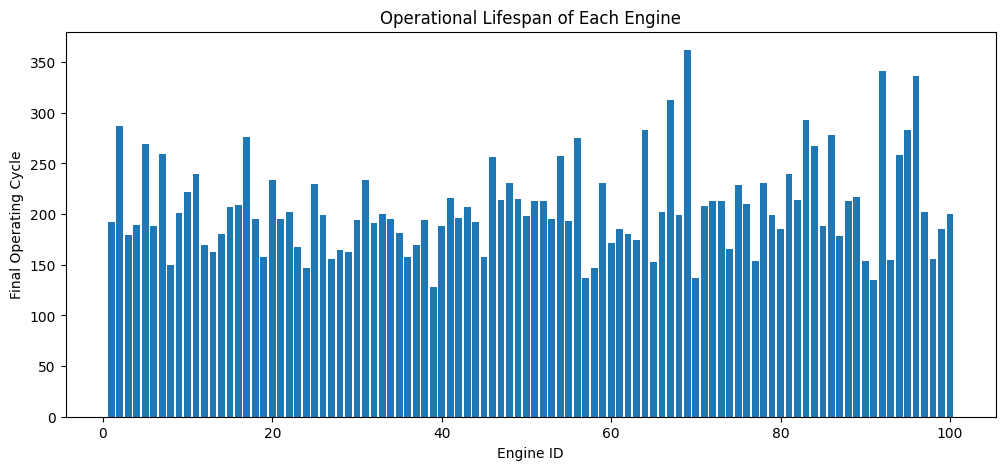

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(engine_life.index, engine_life.values)

plt.xlabel("Engine ID")
plt.ylabel("Final Operating Cycle")
plt.title("Operational Lifespan of Each Engine")

plt.show()

In [9]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

sensor_cycle_corr = df[sensor_columns + ["cycle"]].corr()["cycle"].drop("cycle")

sensor_cycle_corr = sensor_cycle_corr.sort_values()

sensor_cycle_corr

,cycle
sensor_12,-0.611354
sensor_7,-0.595914
sensor_21,-0.585923
sensor_20,-0.583597
sensor_6,0.105980
sensor_14,0.370324
sensor_9,0.443999
sensor_8,0.475977
sensor_13,0.477523
sensor_3,0.543947


In [10]:
top_positive = sensor_cycle_corr.nlargest(3)
top_negative = sensor_cycle_corr.nsmallest(3)

print("Strongest positive relationships:")
print(top_positive)

print("\nStrongest negative relationships:")
print(top_negative)

Strongest positive relationships:
sensor_11    0.634385
sensor_4     0.624577
sensor_15    0.588676
Name: cycle, dtype: float64

Strongest negative relationships:
sensor_12   -0.611354
sensor_7    -0.595914
sensor_21   -0.585923
Name: cycle, dtype: float64


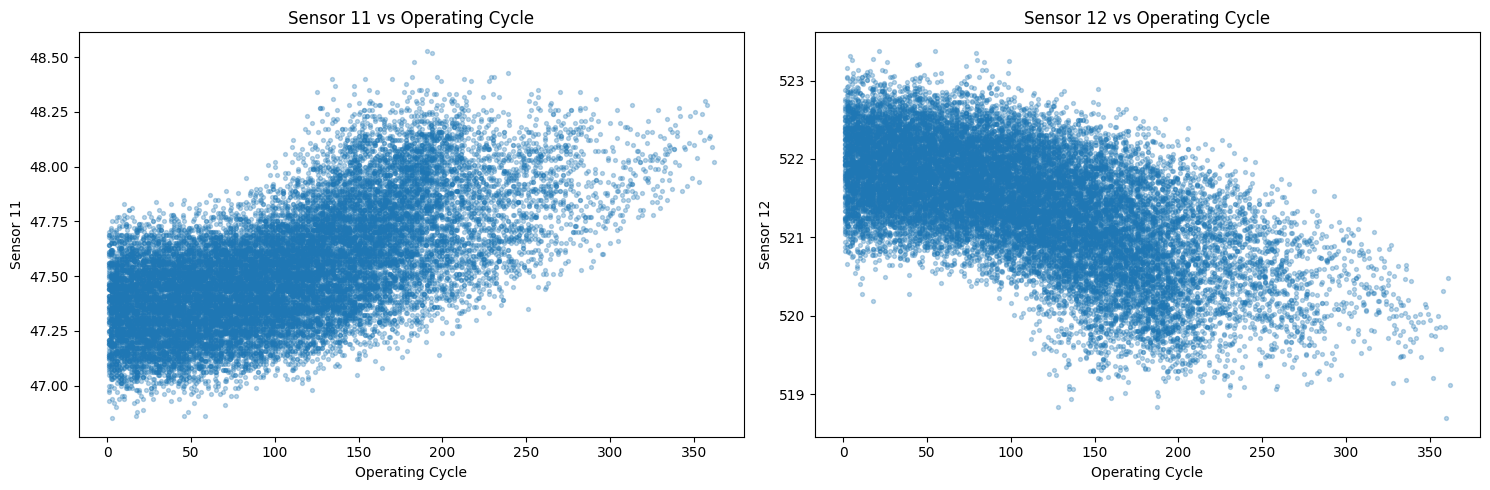

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sensor 11
axes[0].scatter(df["cycle"], df["sensor_11"], s=8, alpha=0.3)
axes[0].set_title("Sensor 11 vs Operating Cycle")
axes[0].set_xlabel("Operating Cycle")
axes[0].set_ylabel("Sensor 11")

# Sensor 12
axes[1].scatter(df["cycle"], df["sensor_12"], s=8, alpha=0.3)
axes[1].set_title("Sensor 12 vs Operating Cycle")
axes[1].set_xlabel("Operating Cycle")
axes[1].set_ylabel("Sensor 12")

plt.tight_layout()
plt.show()

In [12]:
df["max_cycle"] = df.groupby("engine_id")["cycle"].transform("max")

df["lifecycle_pct"] = (df["cycle"] / df["max_cycle"]) * 100

df[["engine_id", "cycle", "max_cycle", "lifecycle_pct"]].head()

,engine_id,cycle,max_cycle,lifecycle_pct
0,1,1,192,0.520833
1,1,2,192,1.041667
2,1,3,192,1.562500
3,1,4,192,2.083333
4,1,5,192,2.604167


In [13]:
df["lifecycle_stage"] = pd.cut(
    df["lifecycle_pct"],
    bins=[0, 25, 50, 75, 100],
    labels=["Early", "Mid-Early", "Mid-Late", "Late"],
    include_lowest=True
)

df["lifecycle_stage"].value_counts().sort_index()

,count
lifecycle_stage,
Early,5118
Mid-Early,5172
Mid-Late,5145
Late,5196


In [14]:
key_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_15",
    "sensor_12",
    "sensor_7",
    "sensor_21"
]

stage_means = df.groupby("lifecycle_stage", observed=True)[key_sensors].mean()

stage_means

,sensor_11,sensor_4,sensor_15,sensor_12,sensor_7,sensor_21
lifecycle_stage,,,,,,
Early,47.354500,1402.775563,8.418241,521.909060,553.946116,23.358816
Mid-Early,47.408699,1404.598426,8.424682,521.768277,553.785298,23.338931
Mid-Late,47.534371,1408.663083,8.440875,521.433810,553.392062,23.292179
Late,47.863622,1419.582929,8.484333,520.552011,552.358220,23.170185


In [15]:
early_values = stage_means.loc["Early"]
late_values = stage_means.loc["Late"]

percentage_change = ((late_values - early_values) / early_values.abs()) * 100

percentage_change.sort_values()

,0
sensor_21,-0.807535
sensor_7,-0.286652
sensor_12,-0.260016
sensor_15,0.785108
sensor_11,1.075130
sensor_4,1.198151


In [16]:
normalized_stage_means = (stage_means / stage_means.loc["Early"]) * 100

normalized_stage_means

,sensor_11,sensor_4,sensor_15,sensor_12,sensor_7,sensor_21
lifecycle_stage,,,,,,
Early,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
Mid-Early,100.114454,100.129947,100.076519,99.973025,99.970969,99.914871
Mid-Late,100.379840,100.419705,100.268868,99.908940,99.899981,99.714726
Late,101.075130,101.198151,100.785108,99.739984,99.713348,99.192465


In [17]:
sensor_strength = sensor_cycle_corr.abs().sort_values(ascending=False)

sensor_strength

,cycle
sensor_11,0.634385
sensor_4,0.624577
sensor_12,0.611354
sensor_7,0.595914
sensor_15,0.588676
sensor_21,0.585923
sensor_20,0.583597
sensor_17,0.566995
sensor_2,0.549898
sensor_3,0.543947


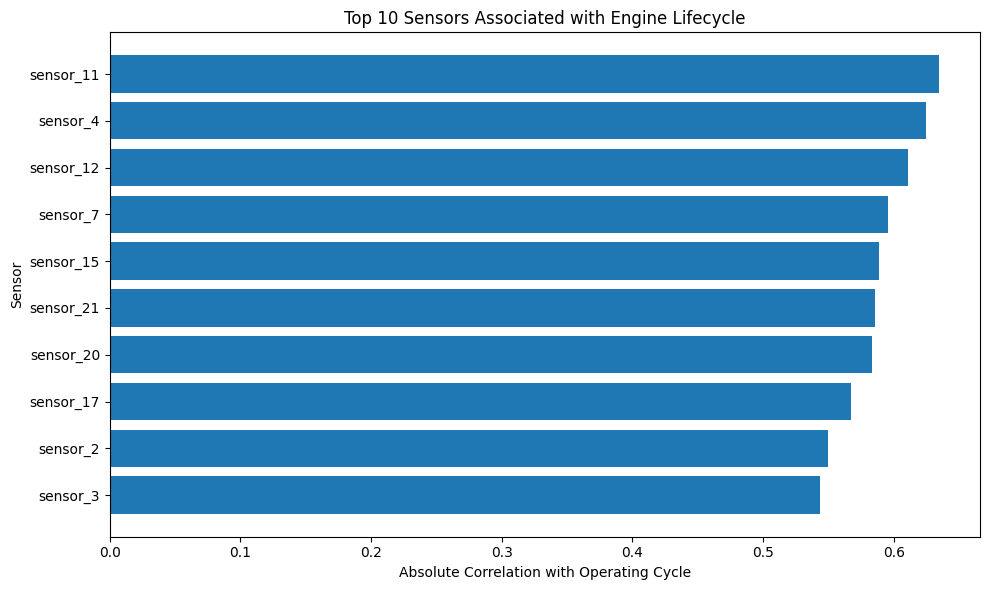

In [18]:
top_sensors = sensor_strength.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top_sensors.index, top_sensors.values)

plt.xlabel("Absolute Correlation with Operating Cycle")
plt.ylabel("Sensor")
plt.title("Top 10 Sensors Associated with Engine Lifecycle")

plt.tight_layout()
plt.show()

## 8. Key Findings

The analysis identified several sensor signals that exhibit consistent
directional changes as engines progress through their operational lifecycle.

### Key Observations

- Several sensors show positive relationships with operating cycle,
  indicating gradual increases across the lifecycle.
- Other sensors show negative relationships, indicating gradual decreases.
- The strongest signals do not necessarily change dramatically; instead,
  their behavior shows gradual directional drift.
- Comparing normalized lifecycle stages provides a more meaningful view
  than comparing absolute cycle numbers across engines with different
  lifespans.

These patterns suggest that engine degradation is reflected through
multiple sensor signals rather than a single dominant measurement.

## 9. Conclusion

This exploratory analysis demonstrates how multivariate sensor data can be
used to identify potential indicators of engine lifecycle progression.

The analysis found multiple sensor signals with consistent directional
relationships across the operational lifecycle. By combining correlation
analysis with normalized lifecycle comparisons, the study provides a clearer
view of how sensor behavior evolves from early to late engine operation.

### Key Takeaway

> **Engine degradation appears as a gradual shift across multiple sensor
> signals rather than an abrupt change in a single measurement.**

These findings could serve as a foundation for more advanced work such as
engine health scoring, anomaly detection, or Remaining Useful Life prediction.
However, those predictive approaches are outside the scope of this
exploratory analysis.